# SpaceX Falcon 9 First Stage Landing Prediction
## Lab 8: Machine Learning Prediction

We standardize the engineered features, split the data into training and test sets, and tune four classifiers (Logistic Regression, Support Vector Machine, Decision Tree and K-Nearest Neighbors) with 10-fold `GridSearchCV`. Finally we compare their accuracy on the test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

sns.set_theme(style="white")

In [2]:
def plot_confusion_matrix(y, y_predict, title, filename=None):
    cm = confusion_matrix(y, y_predict)
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 18})
    ax.set_xlabel('Predicted labels', fontsize=13)
    ax.set_ylabel('True labels', fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.xaxis.set_ticklabels(['did not land', 'landed'])
    ax.yaxis.set_ticklabels(['did not land', 'landed'])
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

In [3]:
data = pd.read_csv("dataset_part_2.csv")
X = pd.read_csv("dataset_part_3.csv")
X.shape

(90, 80)

### Task 1: Create a NumPy array from the column Class

In [4]:
Y = data['Class'].to_numpy()
Y[:10]

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0])

### Task 2: Standardize the data in X

In [5]:
transform = preprocessing.StandardScaler()
X = transform.fit(X).transform(X)
X[:2]

array([[-1.71291154e+00, -1.94814463e-16, -6.53912840e-01,
        -1.87082869e+00, -8.35531692e-01, -1.93309133e+00,
        -1.57589457e+00, -9.73440458e-01, -1.05999788e-01,
        -1.05999788e-01, -6.54653671e-01, -1.05999788e-01,
        -5.51677284e-01,  3.44342023e+00, -1.85695338e-01,
        -3.33333333e-01, -1.05999788e-01, -2.42535625e-01,
        -4.29197538e-01,  7.97724035e-01, -5.68796459e-01,
        -4.10890702e-01, -4.10890702e-01, -1.50755672e-01,
        -7.97724035e-01, -1.50755672e-01, -3.92232270e-01,
         9.43398113e+00, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.50755672e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-0

### Task 3: Split the data into training and test sets

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
print('Train set:', X_train.shape, ' Test set:', X_test.shape)

Train set: (72, 80)  Test set: (18, 80)


### Task 4 & 5: Logistic Regression

In [7]:
parameters = {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr = LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)
print("tuned hyperparameters (best parameters):", logreg_cv.best_params_)
print("accuracy (cross-validation):", logreg_cv.best_score_)

tuned hyperparameters (best parameters): {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy (cross-validation): 0.8214285714285714


test accuracy: 0.8333333333333334


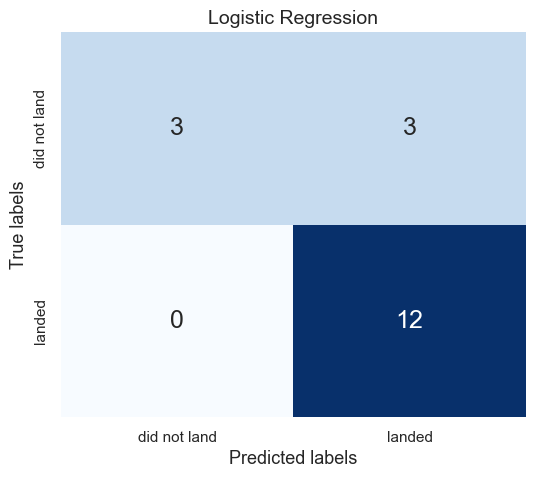

In [8]:
print("test accuracy:", logreg_cv.score(X_test, Y_test))
plot_confusion_matrix(Y_test, logreg_cv.predict(X_test), 'Logistic Regression')

### Task 6 & 7: Support Vector Machine

In [9]:
parameters = {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma': np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)
print("tuned hyperparameters (best parameters):", svm_cv.best_params_)
print("accuracy (cross-validation):", svm_cv.best_score_)

tuned hyperparameters (best parameters): {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}
accuracy (cross-validation): 0.8482142857142858


test accuracy: 0.8333333333333334


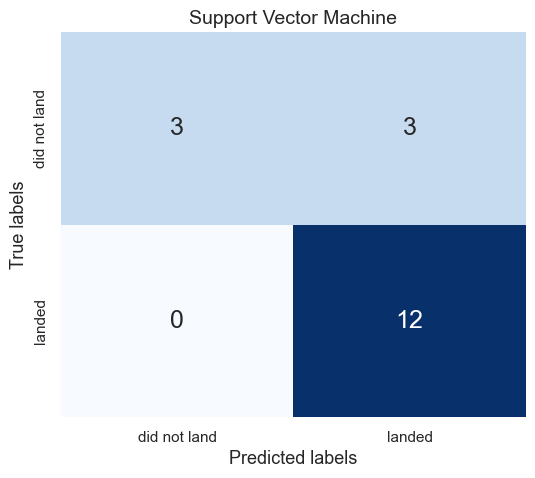

In [10]:
print("test accuracy:", svm_cv.score(X_test, Y_test))
plot_confusion_matrix(Y_test, svm_cv.predict(X_test), 'Support Vector Machine')

### Task 8 & 9: Decision Tree

In [11]:
parameters = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'max_depth': [2 * n for n in range(1, 10)],
              'max_features': ['sqrt', 'log2'],
              'min_samples_leaf': [1, 2, 4],
              'min_samples_split': [2, 5, 10]}
tree = DecisionTreeClassifier(random_state=2)
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)
print("tuned hyperparameters (best parameters):", tree_cv.best_params_)
print("accuracy (cross-validation):", tree_cv.best_score_)

tuned hyperparameters (best parameters): {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
accuracy (cross-validation): 0.8339285714285714


test accuracy: 0.7222222222222222


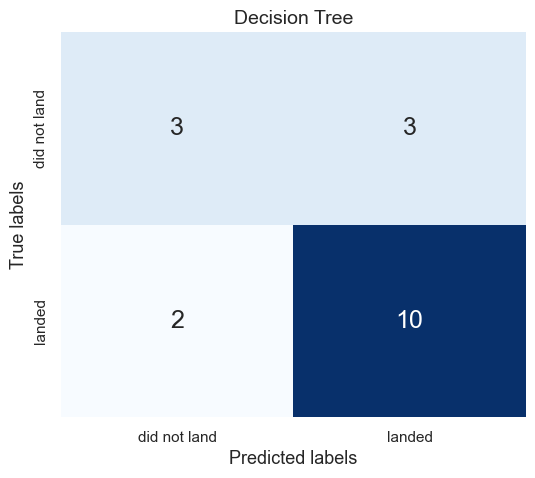

In [12]:
print("test accuracy:", tree_cv.score(X_test, Y_test))
plot_confusion_matrix(Y_test, tree_cv.predict(X_test), 'Decision Tree')

### Task 10 & 11: K-Nearest Neighbors

In [13]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1, 2]}
KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(KNN, parameters, cv=10)
knn_cv.fit(X_train, Y_train)
print("tuned hyperparameters (best parameters):", knn_cv.best_params_)
print("accuracy (cross-validation):", knn_cv.best_score_)

tuned hyperparameters (best parameters): {'algorithm': 'auto', 'n_neighbors': 6, 'p': 1}
accuracy (cross-validation): 0.8339285714285714


test accuracy: 0.8333333333333334


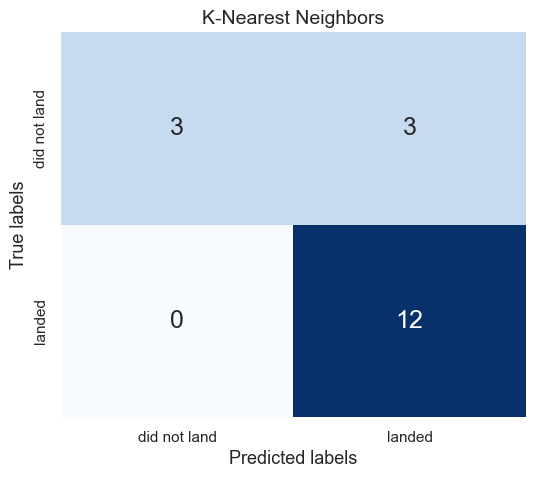

In [14]:
print("test accuracy:", knn_cv.score(X_test, Y_test))
plot_confusion_matrix(Y_test, knn_cv.predict(X_test), 'K-Nearest Neighbors')

### Task 12: Find the method that performs best

In [15]:
models = {'Logistic Regression': logreg_cv, 'SVM': svm_cv, 'Decision Tree': tree_cv, 'KNN': knn_cv}
results = pd.DataFrame({
    'Model': list(models.keys()),
    'CV Accuracy': [m.best_score_ for m in models.values()],
    'Test Accuracy': [m.score(X_test, Y_test) for m in models.values()],
}).round(4)
results

,Model,CV Accuracy,Test Accuracy
0,Logistic Regression,0.8214,0.8333
1,SVM,0.8482,0.8333
2,Decision Tree,0.8339,0.7222
3,KNN,0.8339,0.8333


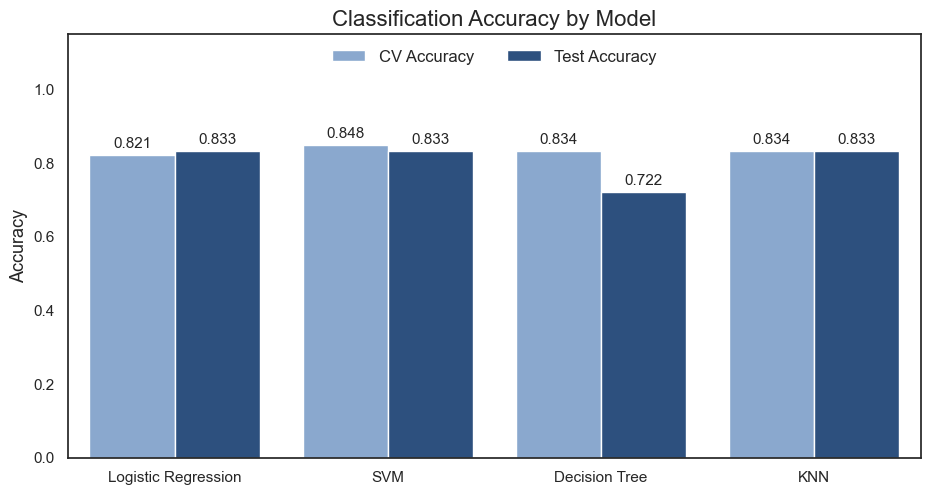

In [16]:
plot_df = results.melt(id_vars='Model', var_name='Metric', value_name='Accuracy')
plt.figure(figsize=(11, 5.5))
ax = sns.barplot(x='Model', y='Accuracy', hue='Metric', data=plot_df, palette=['#7fa7d9', '#1f4e8c'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=11, padding=3)
plt.ylim(0, 1.15)
plt.title('Classification Accuracy by Model', fontsize=16)
plt.xlabel('')
plt.ylabel('Accuracy', fontsize=13)
plt.legend(loc='upper center', ncol=2, frameon=False, fontsize=12)
plt.savefig('images/ml_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
best = results.sort_values(['Test Accuracy', 'CV Accuracy'], ascending=False).iloc[0]
best_name = best['Model']
print('Best model:', best_name)
print('Test accuracy:', best['Test Accuracy'], ' CV accuracy:', best['CV Accuracy'])
print('Best parameters:', models[best_name].best_params_)

Best model: SVM
Test accuracy: 0.8333  CV accuracy: 0.8482
Best parameters: {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}


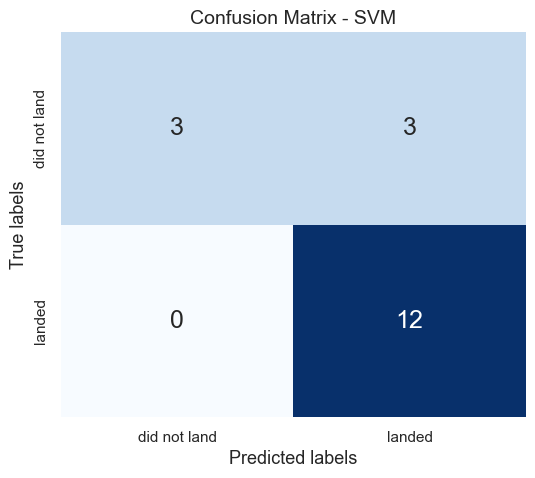

In [18]:
plot_confusion_matrix(Y_test, models[best_name].predict(X_test), 'Confusion Matrix - ' + best_name, 'images/ml_confusion_matrix.png')